# Isolation Forest

Build an unsupervised model that separates benign from non-benign packets.

Isolation Forest is an unsupervised anomaly detection method. Instead of forming clusters, it builds many random isolation trees. Points that can be isolated using fewer splits are considered more unusual. This makes the method useful for this project because attack packets are expected to be a small minority of the sample.

For this Phase 2 detector, the model is trained on packet-level features only. Labels are not used during training. After training, each packet receives an anomaly score, and packets with scores above a selected threshold are marked as initial alerts.


## Setup, load metadata and sampled packet dataset


In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"

## load packet dataset and metadata
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME

with open(META_PATH, "r") as f:
    metadata = json.load(f)

DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()


(205041, 138)


,stream,src_mac,dst_mac,src_ip,dst_ip,src_port,dst_port,inter_arrival_time,time_since_previously_displayed_frame,port_class_dst,...,med_p,average_p,var_p,q3_p,q1_p,iqr_p,l3_ip_dst_count,attack_type,binary_label,source_file
0,3308,ac:17:02:05:34:27,3c:18:a0:41:c3:a0,192.168.137.41,109.95.152.66,38816,443,2109.894808,0.000185,1,...,12.0,196.00,423167.578947,19.0,12.0,7.0,9.0,Benign,benign,BenignTraffic.csv
1,7463,3c:18:a0:41:c3:a0,ac:17:02:05:34:27,157.249.81.141,192.168.137.41,443,60200,4848.002092,0.000290,3,...,15.5,58.65,10582.239474,32.0,12.0,20.0,9.0,Benign,benign,BenignTraffic.csv
2,3000,ac:17:02:05:34:27,3c:18:a0:41:c3:a0,192.168.137.41,157.249.81.141,54061,443,1901.971732,0.003855,1,...,19.5,33.35,2097.081579,28.0,12.0,16.0,9.0,Benign,benign,BenignTraffic.csv
3,27,Amazon Echo Show,Amazon Echo Dot 2,192.168.137.172,192.168.137.58,55444,55444,3902.830519,0.003104,3,...,18.0,18.00,0.000000,18.0,18.0,0.0,50.0,Benign,benign,BenignTraffic.csv
4,0,3c:18:a0:41:c3:a0,Arlo Q Indoor Camera,99.81.244.93,192.168.137.175,443,56891,23.178632,0.000001,3,...,1460.0,1242.80,502105.431579,1460.0,1460.0,0.0,3.0,Benign,benign,BenignTraffic.csv


In [2]:
## check class imbalance
BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"

print(df[BINARY_COL].value_counts())
print()
print(df[ATTACK_COL].value_counts())

## Create numeric labels for evaluation only.
## These labels are not used to train Isolation Forest.
y_true = df[BINARY_COL].map({
    "benign": 0,
    "attack": 1
}).to_numpy()


binary_label
benign    200000
attack      5041
Name: count, dtype: int64

attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## Data Preprocessing




### Isolation Forest feature selection

The feature selection step is kept similar to the K-Means notebook. I remove label columns and text-like identifier columns such as IP addresses, MAC addresses, host names, URI strings, and user agents. These fields are useful for network interpretation, but directly using them as numeric model inputs would either fail or create artificial patterns.

Only numeric packet-level features are used for the first Isolation Forest implementation. This keeps the model simple and makes the results easier to explain.


In [3]:
label_cols = [BINARY_COL, ATTACK_COL]

# These columns are identifiers or text-like fields, so do not use them first.
drop_cols = [
    "src_ip", "dst_ip",
    "src_mac", "dst_mac",
    "device_mac",
    "eth_src_oui", "eth_dst_oui",
    "http_host", "http_uri", "http_content_type",
    "http_request_method", "user_agent",
    "dns_server", "tls_server",
    "highest_layer"
]

drop_cols = [col for col in drop_cols if col in df.columns]
label_cols = [col for col in label_cols if col in df.columns]

feature_df = df.drop(columns=label_cols + drop_cols)

numeric_cols = feature_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
X_raw = feature_df[numeric_cols].copy()

print("Number of numeric features:", X_raw.shape[1])
X_raw.head()


Number of numeric features: 119


,stream,src_port,dst_port,inter_arrival_time,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,...,sum_p,min_p,max_p,med_p,average_p,var_p,q3_p,q1_p,iqr_p,l3_ip_dst_count
0,3308,38816,443,2109.894808,0.000185,1,1,0,64,60,...,3920.0,6.0,2908.0,12.0,196.00,423167.578947,19.0,12.0,7.0,9.0
1,7463,443,60200,4848.002092,0.000290,3,1,0,49,66,...,1173.0,12.0,387.0,15.5,58.65,10582.239474,32.0,12.0,20.0,9.0
2,3000,54061,443,1901.971732,0.003855,1,1,0,64,74,...,667.0,12.0,208.0,19.5,33.35,2097.081579,28.0,12.0,16.0,9.0
3,27,55444,55444,3902.830519,0.003104,3,0,1,64,60,...,360.0,18.0,18.0,18.0,18.00,0.000000,18.0,18.0,0.0,50.0
4,0,443,56891,23.178632,0.000001,3,1,0,231,66,...,24856.0,12.0,2908.0,1460.0,1242.80,502105.431579,1460.0,1460.0,0.0,3.0


### Basic preprocessing

Need to:<br>
&emsp;replace inf values<br>
&emsp;impute missing values with median<br>
&emsp;remove completely empty columns<br>
&emsp;remove constant columns<br>
&emsp;scale features<br>

Missing and infinite values were replaced because packet-level network features can contain undefined values, especially in variance, jitter, and rate-related columns. Median imputation is used because it is simple and less sensitive to extreme values than mean imputation. Constant columns are removed because they do not help the model separate normal and unusual packets.

Isolation Forest is not as sensitive to scaling as K-Means, but I still use standard scaling to keep preprocessing consistent across Phase 2 models and to make the PCA visualization more meaningful.


In [4]:
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

# Remove columns that are completely empty
X_raw = X_raw.dropna(axis=1, how="all")

# Remove constant columns
constant_cols = X_raw.columns[X_raw.nunique(dropna=True) <= 1]
X_raw = X_raw.drop(columns=constant_cols)

print("Features after cleaning:", X_raw.shape[1])

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = preprocess.fit_transform(X_raw)

print(X.shape)


Features after cleaning: 118
(205041, 118)


## Training and Tunning

### Tune Isolation Forest hyperparameters

The main Isolation Forest hyperparameters I tune are:

- `n_estimators`: number of trees in the forest. More trees usually give more stable anomaly scores but require more time.
- `max_samples`: number of samples used to build each tree. Smaller values are faster, while larger values may capture more packet variation.
- alert threshold: the percentage of packets marked as anomalous.

Since this is an unsupervised model, labels are not used when fitting the model. I first compare runtime and anomaly-score separation for several model settings. Then I use an expected alert rate near the project sampling design, around 2–3%, to convert anomaly scores into alerts.


In [5]:
n_estimators_values = [100, 200, 300]
max_samples_values = [256, 1024, 4096]

tuning_results = []

for n_estimators in n_estimators_values:
    for max_samples in max_samples_values:
        start = time.time()

        model = IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            contamination="auto",
            random_state=1,
            n_jobs=-1
        )

        model.fit(X)
        scores = -model.score_samples(X)   # larger score = more anomalous

        runtime = time.time() - start

        # This is an unsupervised summary, not a label-based metric.
        top_rate = 0.025
        threshold = np.quantile(scores, 1 - top_rate)
        pred = (scores >= threshold).astype(int)

        score_gap = scores[pred == 1].mean() - scores[pred == 0].mean()

        tuning_results.append({
            "n_estimators": n_estimators,
            "max_samples": max_samples,
            "score_gap": score_gap,
            "runtime_sec": runtime,
            "alert_rate": pred.mean()
        })

iforest_tuning_df = pd.DataFrame(tuning_results)
iforest_tuning_df


,n_estimators,max_samples,score_gap,runtime_sec,alert_rate
0,100,256,0.282146,0.594391,0.025005
1,100,1024,0.252645,0.750523,0.025005
2,100,4096,0.211482,0.938588,0.025005
3,200,256,0.284700,1.303386,0.025005
4,200,1024,0.247496,1.536580,0.025005
5,200,4096,0.209647,1.869234,0.025005
6,300,256,0.279436,1.697729,0.025005
7,300,1024,0.246252,2.507504,0.025005
8,300,4096,0.207231,2.833114,0.025005


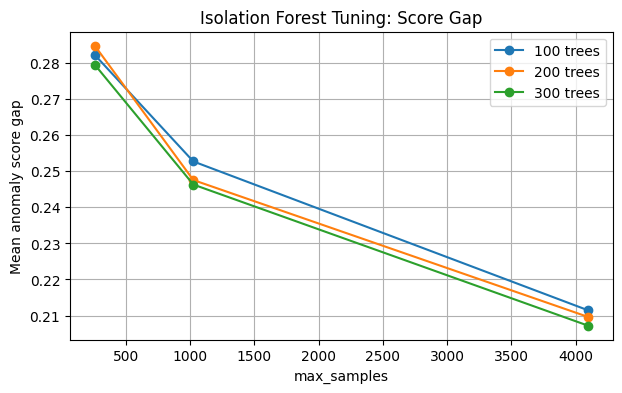

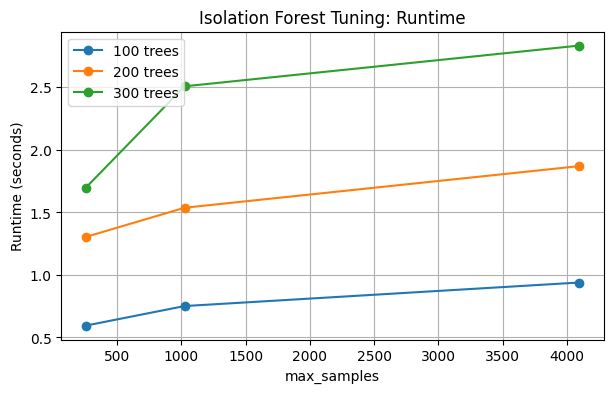

In [6]:
plt.figure(figsize=(7, 4))
for n_estimators in n_estimators_values:
    temp = iforest_tuning_df[iforest_tuning_df["n_estimators"] == n_estimators]
    plt.plot(temp["max_samples"], temp["score_gap"], marker="o", label=f"{n_estimators} trees")

plt.xlabel("max_samples")
plt.ylabel("Mean anomaly score gap")
plt.title("Isolation Forest Tuning: Score Gap")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
for n_estimators in n_estimators_values:
    temp = iforest_tuning_df[iforest_tuning_df["n_estimators"] == n_estimators]
    plt.plot(temp["max_samples"], temp["runtime_sec"], marker="o", label=f"{n_estimators} trees")

plt.xlabel("max_samples")
plt.ylabel("Runtime (seconds)")
plt.title("Isolation Forest Tuning: Runtime")
plt.legend()
plt.grid(True)
plt.show()


Based on the tuning table and plots, I choose a setting that gives a reasonable anomaly-score gap without making the runtime too large. In this notebook, I use 200 trees and `max_samples = 1024` as a balanced starting point. This is not necessarily the only possible choice, but it is simple, reproducible, and easy to justify for a first Phase 2 Isolation Forest baseline.


### Train Isolation Forest model


In [20]:
BEST_N_ESTIMATORS = 200
BEST_MAX_SAMPLES = 1024

start_train = time.time()

iforest = IsolationForest(
    n_estimators=BEST_N_ESTIMATORS,
    max_samples=BEST_MAX_SAMPLES,
    contamination="auto",
    random_state=1,
    n_jobs=-1
)

iforest.fit(X)

train_time = time.time() - start_train

print("Training time:", train_time)


Training time: 0.5367021560668945


### Generate anomaly scores and alerts

Isolation Forest gives a score for each packet. I convert it so that a larger value means the packet is more anomalous.

The final alert threshold is selected using the expected anomaly rate from the sampling design. The project sample is intentionally imbalanced, with benign traffic making up around 97–98% of the data and attacks around 2–3%. Therefore, I flag approximately the top 2.5% most anomalous packets as initial alerts. This threshold can be adjusted later depending on whether we want lower false positives or lower false negatives.


In [21]:
## Generate anomaly scores
anomaly_score = -iforest.score_samples(X)

df_result = df.copy()
df_result["model"] = "IsolationForest"
df_result["anomaly_score"] = anomaly_score

# Use the project sampling design as the expected alert budget.
# You can also replace this with 0.025 to avoid using exact metadata counts.
expected_attack_rate = metadata["total_attack_rows"] / metadata["total_rows"]

threshold = np.quantile(anomaly_score, 1 - expected_attack_rate)
df_result["y_pred"] = (df_result["anomaly_score"] >= threshold).astype(int)

print("Expected attack rate:", expected_attack_rate)
print("Threshold:", threshold)
print(df_result["y_pred"].value_counts())

df_result[["anomaly_score", "y_pred", BINARY_COL, ATTACK_COL]].head()


Expected attack rate: 0.02458532683707161
Threshold: 0.5603246254901396
y_pred
0    200000
1      5041
Name: count, dtype: int64


,anomaly_score,y_pred,binary_label,attack_type
0,0.379147,0,benign,Benign
1,0.359670,0,benign,Benign
2,0.357346,0,benign,Benign
3,0.335270,0,benign,Benign
4,0.493015,0,benign,Benign


## Evaluation

### Phase 2 evaluation metrics

The project requires Phase 2 packet-level evaluation with precision, recall, F1-score, per-attack detection rate, FPR, FNR, AUC-ROC, and a confusion matrix. The function below keeps the output as one simple table so it can be compared with the K-Means results later.


In [22]:
def evaluate_phase2_detection(y_true, y_pred, scores, attack_types, model_name, runtime_sec):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    auc_roc = roc_auc_score(y_true, scores)

    result = {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "auc_roc": auc_roc,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "runtime_sec": runtime_sec
    }

    # Per-attack detection rate
    attack_names = ["DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]

    for attack in attack_names:
        attack_mask = attack_types == attack

        if attack_mask.sum() > 0:
            detection_rate = y_pred[attack_mask].mean()
        else:
            detection_rate = 0

        col_name = attack.lower().replace(" ", "_").replace("-", "_") + "_detect_rate"
        result[col_name] = detection_rate

    return result


metrics = evaluate_phase2_detection(
    y_true=y_true,
    y_pred=df_result["y_pred"].to_numpy(),
    scores=df_result["anomaly_score"].to_numpy(),
    attack_types=df_result[ATTACK_COL].to_numpy(),
    model_name="IsolationForest",
    runtime_sec=train_time
)

metrics_df = pd.DataFrame([metrics])
metrics_df


,model,accuracy,precision,recall,f1,fpr,fnr,auc_roc,tp,fp,tn,fn,runtime_sec,ddos_http_flood_detect_rate,dos_http_flood_detect_rate,dns_spoofing_detect_rate,brute_force_detect_rate,xss_detect_rate
0,IsolationForest,0.961169,0.210276,0.210276,0.210276,0.019905,0.789724,0.800194,1060,3981,196019,3981,0.536702,0.212485,0.884615,0.170233,0.027228,0.034351


### Threshold sensitivity analysis

The threshold controls the false-positive and false-negative trade-off. A lower alert rate usually reduces false positives but may miss more attacks. A higher alert rate usually catches more attacks but creates more false alarms. The table below tests a few alert rates around the project attack proportion. Labels are used here only for evaluation and analysis, not for model training.


In [23]:
alert_rates = [0.015, 0.020, 0.025, 0.030, 0.040]
threshold_rows = []

for alert_rate in alert_rates:
    temp_threshold = np.quantile(anomaly_score, 1 - alert_rate)
    temp_pred = (anomaly_score >= temp_threshold).astype(int)

    temp_metrics = evaluate_phase2_detection(
        y_true=y_true,
        y_pred=temp_pred,
        scores=anomaly_score,
        attack_types=df_result[ATTACK_COL].to_numpy(),
        model_name=f"IsolationForest_{alert_rate:.3f}",
        runtime_sec=train_time
    )

    temp_metrics["alert_rate"] = alert_rate
    temp_metrics["threshold"] = temp_threshold
    threshold_rows.append(temp_metrics)

threshold_df = pd.DataFrame(threshold_rows)
threshold_df[["model", "alert_rate", "threshold", "precision", "recall", "f1", "fpr", "fnr", "auc_roc", "fp", "fn"]]


,model,alert_rate,threshold,precision,recall,f1,fpr,fnr,auc_roc,fp,fn
0,IsolationForest_0.015,0.015,0.588332,0.257152,0.156913,0.194900,0.011425,0.843087,0.800194,2285,4250
1,IsolationForest_0.020,0.020,0.572320,0.228725,0.186074,0.205207,0.015815,0.813926,0.800194,3163,4103
2,IsolationForest_0.025,0.025,0.559220,0.210454,0.214045,0.212234,0.020240,0.785955,0.800194,4048,3962
3,IsolationForest_0.030,0.030,0.549074,0.197659,0.241222,0.217279,0.024680,0.758778,0.800194,4936,3825
4,IsolationForest_0.040,0.040,0.532229,0.176664,0.287443,0.218833,0.033765,0.712557,0.800194,6753,3592


#### Confusion matrix visualization


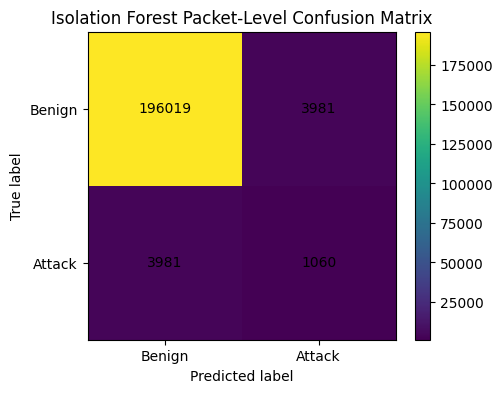

In [11]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    classes = ["Benign", "Attack"]
    plt.xticks([0, 1], classes)
    plt.yticks([0, 1], classes)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()


plot_confusion_matrix(
    y_true,
    df_result["y_pred"].to_numpy(),
    "Isolation Forest Packet-Level Confusion Matrix"
)


#### ROC curve


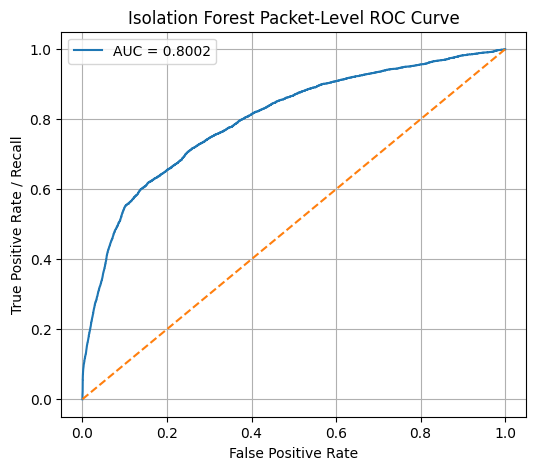

In [12]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc_curve(
    y_true,
    df_result["anomaly_score"].to_numpy(),
    "Isolation Forest Packet-Level ROC Curve"
)


#### Precision-recall curve


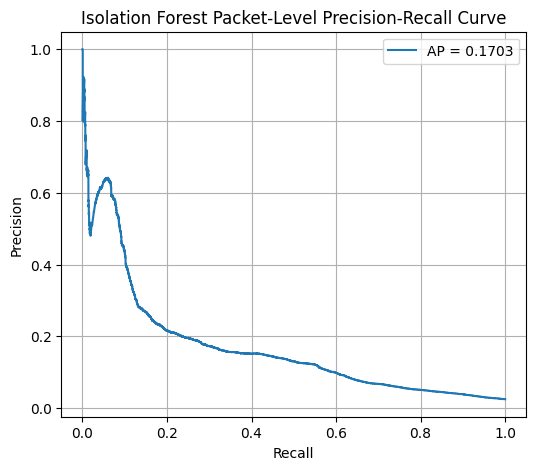

In [13]:
def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_precision_recall_curve(
    y_true,
    df_result["anomaly_score"].to_numpy(),
    "Isolation Forest Packet-Level Precision-Recall Curve"
)


### PCA visualization

Use PCA to reduce the data to 2 dimensions to show clusters in 2D.

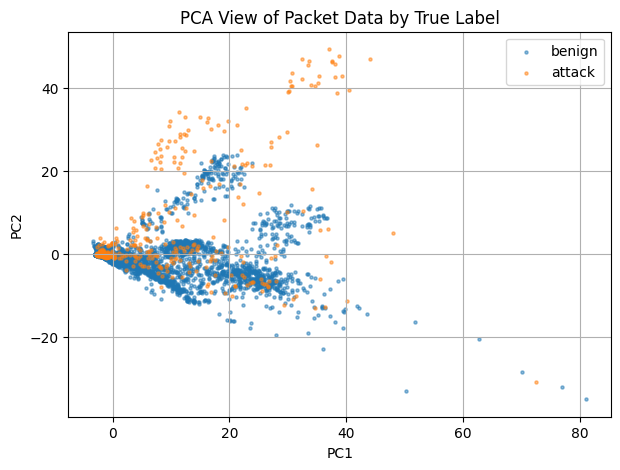

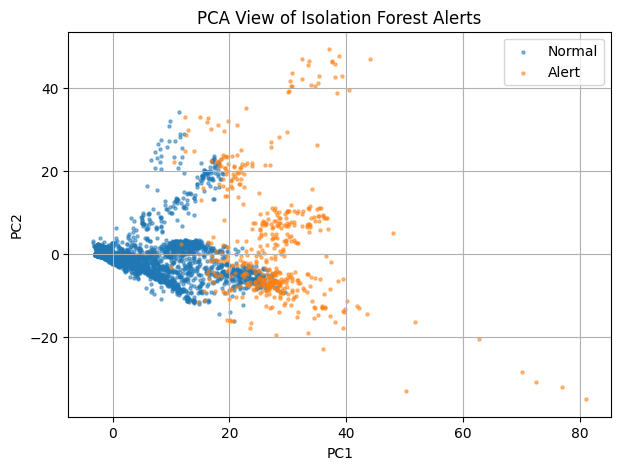

In [14]:
rng = np.random.default_rng(1)

plot_size = min(20000, X.shape[0])
plot_idx = rng.choice(X.shape[0], size=plot_size, replace=False)

pca = PCA(n_components=2, random_state=1)
X_2d = pca.fit_transform(X[plot_idx])

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "binary_label": df_result.iloc[plot_idx][BINARY_COL].to_numpy(),
    "y_pred": df_result.iloc[plot_idx]["y_pred"].to_numpy(),
    "attack_type": df_result.iloc[plot_idx][ATTACK_COL].to_numpy()
})

## Plot by true binary label
plt.figure(figsize=(7, 5))

for label in ["benign", "attack"]:
    temp = plot_df[plot_df["binary_label"] == label]
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of Packet Data by True Label")
plt.legend()
plt.grid(True)
plt.show()


## Plot by predicted alert
plt.figure(figsize=(7, 5))

for label in [0, 1]:
    temp = plot_df[plot_df["y_pred"] == label]
    name = "Normal" if label == 0 else "Alert"
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of Isolation Forest Alerts")
plt.legend()
plt.grid(True)
plt.show()


### Written analysis template

Isolation Forest was used as the second Phase 2 unsupervised anomaly detector. The model was trained on packet-level numeric features only, and the packet labels were not used during training. After preprocessing, the model assigned an anomaly score to each packet. Packets with the highest anomaly scores were treated as initial IDS alerts.

The alert threshold was selected using the expected imbalance of the sampled dataset. Since the sample was designed to contain about 97–98% benign traffic and 2–3% attack traffic, I selected a threshold that flags approximately the top 2.5% most anomalous packets. This gives a reasonable first alert budget for Phase 2. A higher threshold would reduce false positives but may miss more attacks, while a lower threshold would catch more attacks but increase the number of benign packets incorrectly flagged as attacks.

The final evaluation includes precision, recall, F1-score, FPR, FNR, AUC-ROC, confusion matrix, and detection rate for each attack type. This is important because the dataset is highly imbalanced, so accuracy alone is not enough. In an intrusion detection system, recall and FNR are especially important because missed attacks can be costly, while precision and FPR show how many false alarms the system creates.
